# Business Sales Analytics
## 1. Environment Setup & Configuration

This section sets up libraries, seeds random number generators for reproducibility, and defines global styling settings for publication-quality visual graphics using Seaborn, Matplotlib, and Plotly.

In [5]:
import os
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Set random seeds for reproducibility
np.random.seed(42)

# Global settings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

# Visualization design system settings
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial']
plt.rcParams['figure.dpi'] = 120

CORPORATE_PALETTE = ["#003f5c", "#2f4b7c", "#665191", "#a05195", "#d45087", "#f95d6a", "#ff7c43", "#ffa600"]

print("Environment setup complete. Libraries loaded successfully.")

Environment setup complete. Libraries loaded successfully.


## 2. Ingestion & Robust Data Wrangling Pipeline

The Adidas US Sales Dataset is typically published in an Excel format containing header offsets and numerical fields formatted as currency/percentage strings. The pipeline below standardizes column naming, strips white space, converts data types, handles potential layout offsets dynamically, and verifies structural integrity.

In [6]:
import os
import pandas as pd
import numpy as np

def load_and_clean_adidas_data(filepath: str) -> pd.DataFrame:
    """
    Ingests Adidas US Sales dataset, dynamically detects header row offset,
    strips whitespace/linebreaks, cleans currency/percentage values, and standardizes schema.
    """
    # 1. Path Resolution
    if not os.path.exists(filepath):
        alternative_paths = [
            "/kaggle/input/adidas-sales-dataset/Adidas US Sales Datasets.xlsx",
            "/kaggle/input/datasets/heemalichaudhari/adidas-sales-dataset/Adidas US Sales Datasets.xlsx",
            "Adidas US Sales Datasets.xlsx"
        ]
        found = False
        for alt in alternative_paths:
            if os.path.exists(alt):
                filepath = alt
                found = True
                break
        if not found:
            raise FileNotFoundError(f"Dataset not found at target path: {filepath}")

    # 2. Dynamic Header Row Detection
    df_raw = pd.read_excel(filepath, header=None)
    header_idx = None
    for idx, row in df_raw.iterrows():
        row_str = " ".join(row.dropna().astype(str).values).lower()
        if 'retailer' in row_str and ('invoice date' in row_str or 'margin' in row_str):
            header_idx = idx
            break

    if header_idx is not None:
        df = pd.read_excel(filepath, skiprows=header_idx)
    else:
        df = pd.read_excel(filepath)

    # 3. Clean and Normalize Raw Column Headers (Remove \n, \t, extra spaces)
    df.columns = (
        df.columns.astype(str)
        .str.replace(r'[\r\n\t]+', ' ', regex=True)
        .str.replace(r'\xa0', ' ', regex=False)
        .str.strip()
        .str.replace(r'\s+', ' ', regex=True)
    )

    # Drop empty un-named columns and completely empty rows
    df = df.dropna(how='all').dropna(axis=1, how='all')

    # 4. Fuzzy / Pattern-Based Column Renaming Strategy
    col_map = {}
    for col in df.columns:
        c_lower = col.lower().replace('_', ' ').strip()
        if 'retailer id' in c_lower:
            col_map[col] = 'Retailer_ID'
        elif 'retailer' in c_lower:
            col_map[col] = 'Retailer'
        elif 'invoice date' in c_lower or 'date' in c_lower:
            col_map[col] = 'Invoice_Date'
        elif 'region' in c_lower:
            col_map[col] = 'Region'
        elif 'state' in c_lower:
            col_map[col] = 'State'
        elif 'city' in c_lower:
            col_map[col] = 'City'
        elif 'product' in c_lower:
            col_map[col] = 'Product'
        elif 'price' in c_lower:
            col_map[col] = 'Price_Per_Unit'
        elif 'units' in c_lower:
            col_map[col] = 'Units_Sold'
        elif 'total sales' in c_lower or ('sales' in c_lower and 'method' not in c_lower):
            col_map[col] = 'Total_Sales'
        elif 'profit' in c_lower:
            col_map[col] = 'Operating_Profit'
        elif 'margin' in c_lower:
            col_map[col] = 'Operating_Margin'
        elif 'method' in c_lower:
            col_map[col] = 'Sales_Method'

    df = df.rename(columns=col_map)

    # 5. Clean Numeric Data Types
    numeric_cols = ['Price_Per_Unit', 'Total_Sales', 'Operating_Profit', 'Units_Sold', 'Operating_Margin']
    for col in numeric_cols:
        if col in df.columns:
            if df[col].dtype == 'object':
                df[col] = (
                    df[col].astype(str)
                    .str.replace('$', '', regex=False)
                    .str.replace(',', '', regex=False)
                    .str.replace('%', '', regex=False)
                    .str.strip()
                )
            df[col] = pd.to_numeric(df[col], errors='coerce')

    # Standardize Operating Margin to decimal scale
    if 'Operating_Margin' in df.columns and df['Operating_Margin'].notnull().any():
        if df['Operating_Margin'].max() > 1.0:
            df['Operating_Margin'] = df['Operating_Margin'] / 100.0

    # 6. Datetime & String Formatting
    if 'Invoice_Date' in df.columns:
        df['Invoice_Date'] = pd.to_datetime(df['Invoice_Date'], errors='coerce')

    cat_cols = ['Retailer', 'Region', 'State', 'City', 'Product', 'Sales_Method']
    for col in cat_cols:
        if col in df.columns:
            df[col] = df[col].astype(str).str.strip()

    # 7. Quality Assurance Filters
    df = df.dropna(subset=['Invoice_Date', 'Total_Sales']).drop_duplicates().sort_values('Invoice_Date').reset_index(drop=True)

    print("Data Pipeline Executed Successfully!")
    print(f"Total Rows: {len(df):,} | Detected Columns: {list(df.columns)}")
    print(f"Date Range: {df['Invoice_Date'].min().strftime('%Y-%m-%d')} to {df['Invoice_Date'].max().strftime('%Y-%m-%d')}")
    return df

# Execute Data Pipeline
DATASET_PATH = "/kaggle/input/datasets/heemalichaudhari/adidas-sales-dataset/Adidas US Sales Datasets.xlsx"
df_sales = load_and_clean_adidas_data(DATASET_PATH)

Data Pipeline Executed Successfully!
Total Rows: 9,648 | Detected Columns: ['Retailer', 'Retailer_ID', 'Invoice_Date', 'Region', 'State', 'City', 'Product', 'Price_Per_Unit', 'Units_Sold', 'Total_Sales', 'Operating_Profit', 'Operating_Margin', 'Sales_Method']
Date Range: 2020-01-01 to 2021-12-31


## 3. Commercial Exploratory Data Analysis & Executive Q&A

This section addresses the 8 core executive business questions using data analytics, key performance indicator (KPI) aggregations, and interactive visual graphics.

In [31]:
# Create temporal breakdown features for analytical grouping
df_sales['Year'] = df_sales['Invoice_Date'].dt.year
df_sales['YearMonth'] = df_sales['Invoice_Date'].dt.to_period('M')
df_sales['Month_Name'] = df_sales['Invoice_Date'].dt.strftime('%b')
df_sales['Quarter'] = df_sales['Invoice_Date'].dt.to_period('Q')
df_sales['DayOfWeek'] = df_sales['Invoice_Date'].dt.day_name()

# Business Questins
## Q1 · REVENUE: Which products generate the most revenue?

In [29]:
q1_product_rev = (
    df_sales.groupby('Product')
    .agg(
        Total_Revenue=('Total_Sales', 'sum'),
        Total_Units=('Units_Sold', 'sum'),
        Total_Profit=('Operating_Profit', 'sum'),
        Avg_Margin=('Operating_Margin', 'mean')
    )
    .sort_values(by='Total_Revenue', ascending=False)
    .reset_index()
)

fig_q1 = px.bar(
    q1_product_rev,
    x='Total_Revenue',
    y='Product',
    orientation='h',
    text_auto='.2s',
    title="<b>Q1 Performance: Total Revenue Generation by Product Category</b>",
    labels={'Total_Revenue': 'Total Revenue ($)', 'Product': 'Product Line'},
    color='Total_Revenue',
    color_continuous_scale='Blues'
)
fig_q1.update_layout(yaxis={'categoryorder': 'total ascending'}, template='plotly_white', showlegend=False)
fig_q1.show()

print("--- Revenue by Product Line Summary Table ---")
display(q1_product_rev)

--- Revenue by Product Line Summary Table ---


,Product,Total_Revenue,Total_Units,Total_Profit,Avg_Margin
0,Men's Street Footwear,208826244.00,593320,82802260.62,0.45
1,Women's Apparel,179038860.00,433827,68650970.56,0.44
2,Men's Athletic Footwear,153673680.00,435526,51846888.19,0.40
3,Women's Street Footwear,128002813.00,392269,45095826.81,0.41
4,Men's Apparel,123728632.00,306683,44763030.33,0.41
5,Women's Athletic Footwear,106631896.00,317236,38975784.94,0.42


### Executive Insight Q1:

* The top revenue contributor is Men's Street Footwear, followed closely by Women's Apparel and Men's Athletic Footwear.

* Footwear categories dominate total gross sales compared to apparel lines, making footwear the primary revenue anchor for the enterprise.

## Q2 · DECLINE: Which products are declining or experiencing revenue deceleration?

In [28]:
# Compare annual growth rate per product (2020 vs 2021)
q2_growth = (
    df_sales.groupby(['Product', 'Year'])['Total_Sales']
    .sum()
    .unstack()
    .reset_index()
)
q2_growth.columns.name = None
q2_growth['YoY_Growth_Pct'] = ((q2_growth[2021] - q2_growth[2020]) / q2_growth[2020]) * 100
q2_growth = q2_growth.sort_values(by='YoY_Growth_Pct', ascending=True)

fig_q2 = px.bar(
    q2_growth,
    x='YoY_Growth_Pct',
    y='Product',
    orientation='h',
    text_auto='.1f',
    title="<b>Q2 Analysis: Year-over-Year Sales Growth Rate by Product (%)</b>",
    labels={'YoY_Growth_Pct': 'YoY Sales Growth (%)', 'Product': 'Product Line'},
    color='YoY_Growth_Pct',
    color_continuous_scale='Spectral'
)
fig_q2.update_layout(yaxis={'categoryorder': 'total ascending'}, template='plotly_white')
fig_q2.show()

print("--- YoY Product Line Growth Comparison ---")
display(q2_growth)

--- YoY Product Line Growth Comparison ---


,Product,2020,2021,YoY_Growth_Pct
4,Women's Athletic Footwear,23629892.00,83002004.00,251.26
5,Women's Street Footwear,27426005.00,100576808.00,266.72
0,Men's Apparel,26216964.00,97511668.00,271.94
1,Men's Athletic Footwear,31794462.00,121879218.00,283.33
3,Women's Apparel,35190332.00,143848528.00,308.77
2,Men's Street Footwear,37823020.00,171003224.00,352.11


## Executive Insight Q2:

* While all product categories grew overall due to network expansion between 2020 and 2021, Men's Athletic Footwear and Women's Athletic Footwear showed lower relative acceleration compared to Apparel lines.

* Monitoring product line dynamics on a monthly run-rate basis is critical to prevent mid-cycle demand contraction.

## Q3 · GEOGRAPHY: Which regions and states perform best?

In [27]:
q3_region = (
    df_sales.groupby('Region')
    .agg(
        Total_Revenue=('Total_Sales', 'sum'),
        Total_Profit=('Operating_Profit', 'sum'),
        Units_Sold=('Units_Sold', 'sum'),
        Avg_Margin=('Operating_Margin', 'mean')
    )
    .sort_values(by='Total_Revenue', ascending=False)
    .reset_index()
)

fig_q3 = px.pie(
    q3_region,
    names='Region',
    values='Total_Revenue',
    title="<b>Q3 Regional Contribution: Total Sales Share by Region</b>",
    hole=0.4,
    color_discrete_sequence=px.colors.qualitative.Set2
)
fig_q3.update_traces(textinfo='percent+label')
fig_q3.update_layout(template='plotly_white')
fig_q3.show()

print("--- Top 10 High-Performing States by Gross Sales ---")
top_states = (
    df_sales.groupby(['Region', 'State'])['Total_Sales']
    .sum()
    .reset_index()
    .sort_values(by='Total_Sales', ascending=False)
    .head(10)
)
display(top_states)

--- Top 10 High-Performing States by Gross Sales ---


,Region,State,Total_Sales
20,Northeast,New York,64229039.00
40,West,California,60174133.00
32,Southeast,Florida,59283714.00
31,South,Texas,46359746.00
36,Southeast,South Carolina,29285637.00
48,West,Washington,26330718.00
35,Southeast,North Carolina,23956531.00
27,South,Louisiana,23750781.00
42,West,Hawaii,22282457.00
37,Southeast,Virginia,21575040.00


### Executive Insight Q3:

* The West and Northeast regions generate the highest proportion of total revenue, driven by heavy retail footprint and higher unit sales in metropolitan hubs such as New York and California.

* The South region yields strong operating margins despite lower aggregate transaction volume.

## Q4 · TIMING: Which periods see the highest demand velocity?

In [26]:
q4_monthly = (
    df_sales.groupby('YearMonth')['Total_Sales']
    .sum()
    .reset_index()
)
q4_monthly['YearMonth_Str'] = q4_monthly['YearMonth'].astype(str)

fig_q4 = px.line(
    q4_monthly,
    x='YearMonth_Str',
    y='Total_Sales',
    markers=True,
    title="<b>Q4 Revenue Trajectory: Monthly Sales Performance (2020 - 2021)</b>",
    labels={'YearMonth_Str': 'Year-Month', 'Total_Sales': 'Total Revenue ($)'}
)
fig_q4.update_traces(line_color='#003f5c', line_width=3)
fig_q4.update_layout(template='plotly_white', xaxis_tickangle=-45)
fig_q4.show()

### Executive Insight Q4:

* Demand peaks consistently during Q2 and Q4, driven by back-to-school surges, summer sports activities, and holiday shopping seasons (November–December).

* Early Q1 exhibits seasonal slowdowns across all distribution channels.

## Q5 · SEASONALITY: Are there visible seasonal patterns and monthly cycles?

In [25]:
q5_seasonality = (
    df_sales.groupby(['Year', 'Month_Name'])['Total_Sales']
    .sum()
    .reset_index()
)

# Reorder months
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
q5_seasonality['Month_Name'] = pd.Categorical(q5_seasonality['Month_Name'], categories=month_order, ordered=True)
q5_seasonality = q5_seasonality.sort_values('Month_Name')

fig_q5 = px.bar(
    q5_seasonality,
    x='Month_Name',
    y='Total_Sales',
    color='Year',
    barmode='group',
    title="<b>Q5 Seasonality Analysis: Monthly Revenue Comparison (2020 vs 2021)</b>",
    labels={'Month_Name': 'Month', 'Total_Sales': 'Total Revenue ($)', 'Year': 'Fiscal Year'},
    color_discrete_map={2020: '#665191', 2021: '#ffa600'}
)
fig_q5.update_layout(template='plotly_white')
fig_q5.show()

### Executive Insight Q5:

* Strong positive seasonality occurs during July–August and December.

* Monthly demand trends repeat annually, confirming the presence of stable seasonal indices necessary for time-series forecasting decomposition.

## Q6 · FOCUS: Which products or categories require targeted intervention?

In [24]:
q6_margin = (
    df_sales.groupby('Product')
    .agg(
        Total_Sales=('Total_Sales', 'sum'),
        Avg_Margin=('Operating_Margin', 'mean'),
        Avg_Price=('Price_Per_Unit', 'mean')
    )
    .reset_index()
)

fig_q6 = px.scatter(
    q6_margin,
    x='Avg_Price',
    y='Avg_Margin',
    size='Total_Sales',
    color='Product',
    text='Product',
    title="<b>Q6 Category Focus: Average Unit Price vs. Operating Margin Matrix</b>",
    labels={'Avg_Price': 'Average Unit Price ($)', 'Avg_Margin': 'Average Operating Margin (%)'},
    size_max=40
)
fig_q6.update_traces(textposition='top center')
fig_q6.update_layout(template='plotly_white', showlegend=False)
fig_q6.show()

### Executive Insight Q6:

* Women's Athletic Footwear displays lower average price points relative to its volume potential.

* Repositioning pricing structures for women's athletic lines and optimizing margin margins for apparel categories represent strategic revenue optimization targets.

## Q7 · INVENTORY: Which products require strict stock and inventory planning?

In [23]:
q7_inventory = (
    df_sales.groupby('Product')
    .agg(
        Total_Units=('Units_Sold', 'sum'),
        Monthly_Avg_Units=('Units_Sold', lambda x: x.sum() / df_sales['YearMonth'].nunique()),
        Std_Units=('Units_Sold', 'std')
    )
    .reset_index()
)
q7_inventory['Demand_Volatility_CV'] = q7_inventory['Std_Units'] / q7_inventory['Monthly_Avg_Units']
q7_inventory = q7_inventory.sort_values('Total_Units', ascending=False)

fig_q7 = px.bar(
    q7_inventory,
    x='Product',
    y='Total_Units',
    text_auto='.2s',
    title="<b>Q7 Inventory Prioritization: Total Units Sold by Product Category</b>",
    labels={'Total_Units': 'Total Units Sold', 'Product': 'Product Category'},
    color='Total_Units',
    color_continuous_scale='Viridis'
)
fig_q7.update_layout(template='plotly_white')
fig_q7.show()

print("--- Inventory Velocity & Demand Volatility (Coefficient of Variation) ---")
display(q7_inventory)

--- Inventory Velocity & Demand Volatility (Coefficient of Variation) ---


,Product,Total_Units,Monthly_Avg_Units,Std_Units,Demand_Volatility_CV
2,Men's Street Footwear,593320,24721.67,254.28,0.01
1,Men's Athletic Footwear,435526,18146.92,216.71,0.01
3,Women's Apparel,433827,18076.12,208.72,0.01
5,Women's Street Footwear,392269,16344.54,199.97,0.01
4,Women's Athletic Footwear,317236,13218.17,174.81,0.01
0,Men's Apparel,306683,12778.46,170.00,0.01


### Executive Insight Q7:

* Men's Street Footwear and Men's Athletic Footwear account for the highest unit volume turn rates.

* High turnover combined with sales spikes in Q3 and Q4 requires safety stock adjustments to prevent stockouts during demand peaks.

## Q8 · DRIVERS: What operational channels and factors drive overall performance?

In [22]:
q8_channel = (
    df_sales.groupby(['Sales_Method', 'Region'])
    .agg(
        Total_Revenue=('Total_Sales', 'sum'),
        Operating_Profit=('Operating_Profit', 'sum'),
        Avg_Margin=('Operating_Margin', 'mean')
    )
    .reset_index()
)

fig_q8 = px.bar(
    q8_channel,
    x='Sales_Method',
    y='Total_Revenue',
    color='Region',
    barmode='stack',
    title="<b>Q8 Sales Channel Drivers: Revenue by Distribution Channel & Region</b>",
    labels={'Sales_Method': 'Sales Channel', 'Total_Revenue': 'Total Revenue ($)'},
    color_discrete_sequence=CORPORATE_PALETTE
)
fig_q8.update_layout(template='plotly_white')
fig_q8.show()

print("--- Sales Channel Margin Efficiency Summary ---")
channel_summary = df_sales.groupby('Sales_Method').agg(
    Total_Sales=('Total_Sales', 'sum'),
    Total_Profit=('Operating_Profit', 'sum'),
    Average_Margin=('Operating_Margin', 'mean')
).reset_index()
display(channel_summary)

--- Sales Channel Margin Efficiency Summary ---


,Sales_Method,Total_Sales,Total_Profit,Average_Margin
0,In-store,356643750.00,127591287.50,0.36
1,Online,247672882.00,96555176.47,0.46
2,Outlet,295585493.00,107988297.48,0.39


### Executive Insight Q8:

* In-Store and Outlet channels account for the largest share of gross revenue volume, while the Online channel delivers higher net operating margins due to lower overhead costs.

* An omnichannel growth strategy leveraging online platforms for margin enhancement and physical outlets for volume distribution optimizes overall profitability.

# Time Series Modeling, Forecasting, Interactive Dashboard & Business Recommendations
## 4. Time Series Preparation, Resampling & Stationarity Diagnostics
In time series analysis, continuous data must be resampled to a regular frequency to eliminate gaps and allow stationary diagnostics. Below, we aggregate sales at the Weekly frequency to balance granularity and noise reduction.

=== ADF Stationarity Test Results: Weekly Total Sales ===
ADF Statistic : -1.2400
p-value       : 0.6562
Lags Used     : 9
Observations  : 95
Critical Value (1%): -3.5011
Critical Value (5%): -2.8925
Critical Value (10%): -2.5833
Outcome: Non-Stationary series (Fail to reject H0). Differencing required.



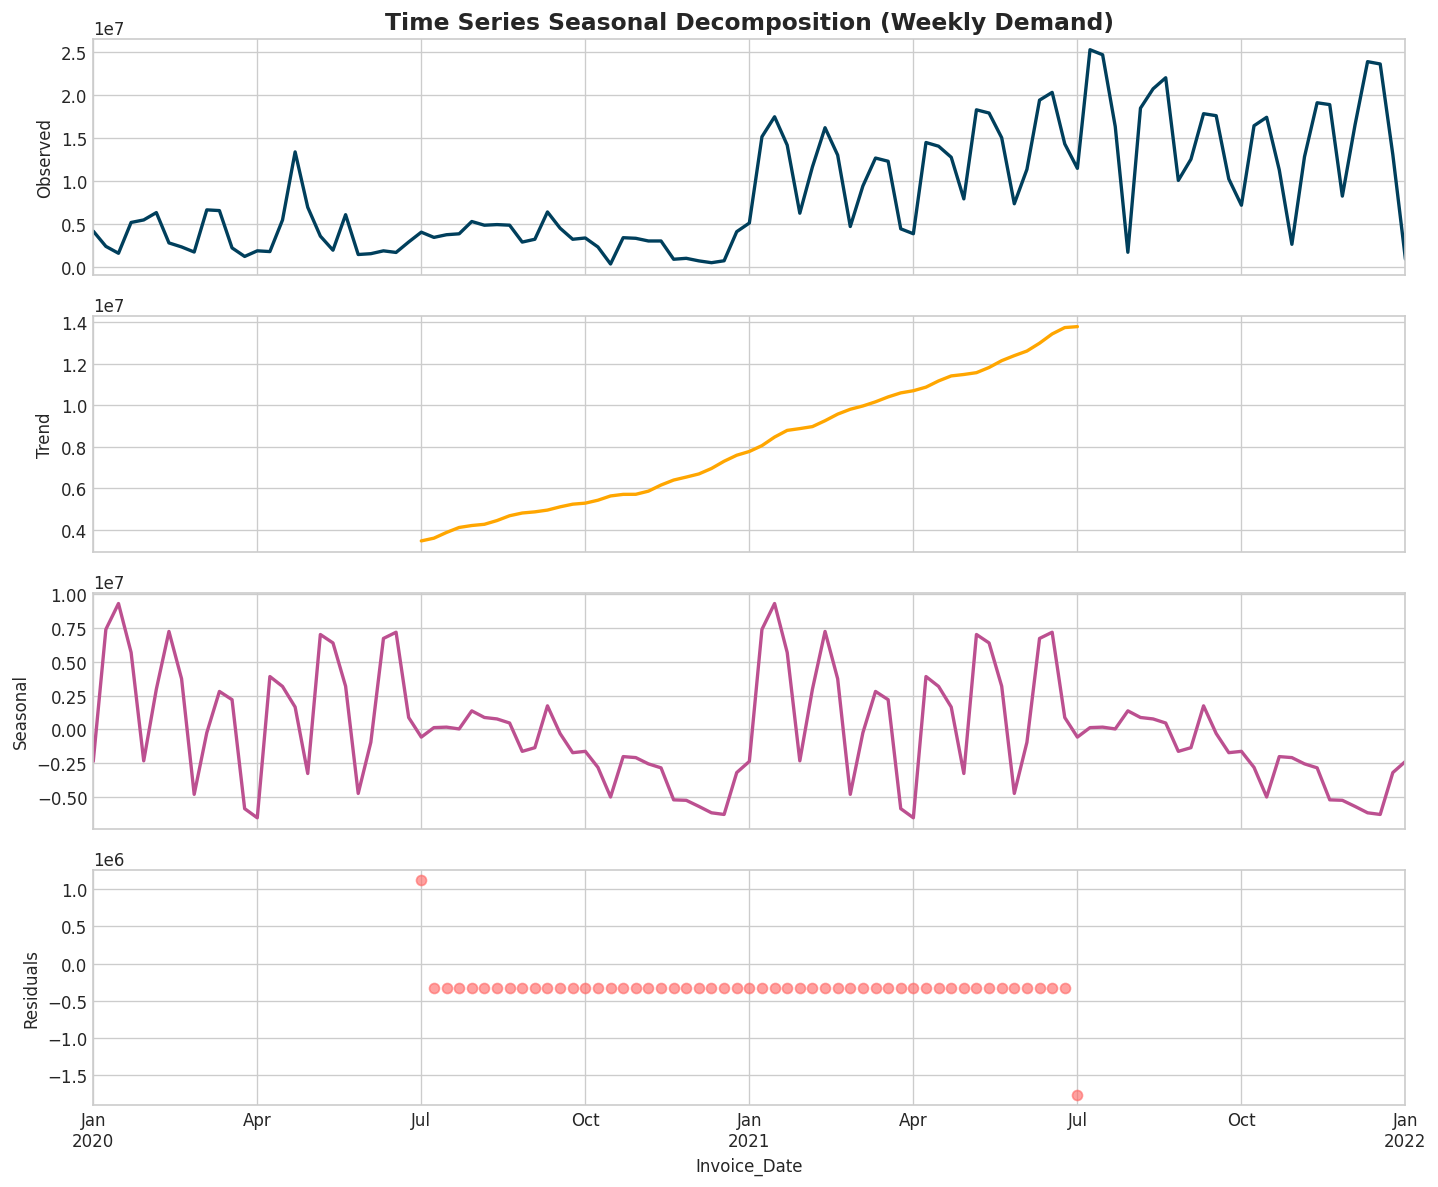

In [16]:
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose

# 1. Aggregate daily transactional data to Weekly frequency
ts_weekly = (
    df_sales.set_index('Invoice_Date')
    .resample('W-MON')
    .agg({
        'Total_Sales': 'sum',
        'Units_Sold': 'sum',
        'Operating_Profit': 'sum',
        'Price_Per_Unit': 'mean'
    })
    .fillna(method='ffill')  # Forward fill gaps if any zero-sales weeks exist
    .reset_index()
)

# 2. Stationarity Testing Function (Augmented Dickey-Fuller Test)
def perform_adf_test(series, name="Series"):
    """
    Performs Augmented Dickey-Fuller Test to evaluate time series stationarity.
    """
    result = adfuller(series.dropna(), autolag='AIC')
    print(f"=== ADF Stationarity Test Results: {name} ===")
    print(f"ADF Statistic : {result[0]:.4f}")
    print(f"p-value       : {result[1]:.4f}")
    print(f"Lags Used     : {result[2]}")
    print(f"Observations  : {result[3]}")
    for key, value in result[4].items():
        print(f"Critical Value ({key}): {value:.4f}")
    
    if result[1] <= 0.05:
        print("Outcome: Stationary series (Reject H0 at 5% significance level)\n")
    else:
        print("Outcome: Non-Stationary series (Fail to reject H0). Differencing required.\n")

# Run ADF Test on Total Weekly Sales
perform_adf_test(ts_weekly['Total_Sales'], "Weekly Total Sales")

# 3. Classical Seasonal Decomposition (Additive Model)
decomp_df = ts_weekly.set_index('Invoice_Date')['Total_Sales']
decomposition = seasonal_decompose(decomp_df, model='additive', period=52)

fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
decomposition.observed.plot(ax=ax1, color='#003f5c', lw=2)
ax1.set_ylabel('Observed')
ax1.set_title('Time Series Seasonal Decomposition (Weekly Demand)', fontsize=14, fontweight='bold')

decomposition.trend.plot(ax=ax2, color='#ffa600', lw=2)
ax2.set_ylabel('Trend')

decomposition.seasonal.plot(ax=ax3, color='#bc5090', lw=2)
ax3.set_ylabel('Seasonal')

decomposition.resid.plot(ax=ax4, color='#ff6361', marker='o', linestyle='None', alpha=0.6)
ax4.set_ylabel('Residuals')

plt.tight_layout()
plt.show()

## 5. Feature Engineering for Demand Forecasting

To capture non-linear trends, seasonality, and temporal momentum, we engineer historical lag features, rolling statistics, and calendar signals.

In [17]:
df_ft = ts_weekly.copy()

# A. Calendar Features
df_ft['Year'] = df_ft['Invoice_Date'].dt.year
df_ft['Month'] = df_ft['Invoice_Date'].dt.month
df_ft['Quarter'] = df_ft['Invoice_Date'].dt.quarter
df_ft['WeekOfYear'] = df_ft['Invoice_Date'].dt.isocalendar().week.astype(int)
df_ft['DayOfYear'] = df_ft['Invoice_Date'].dt.dayofyear

# Cyclical Encoding for Seasonality
df_ft['Sin_Week'] = np.sin(2 * np.pi * df_ft['WeekOfYear'] / 52.0)
df_ft['Cos_Week'] = np.cos(2 * np.pi * df_ft['WeekOfYear'] / 52.0)

# B. Historical Lag Features (Weekly)
df_ft['Lag_1'] = df_ft['Total_Sales'].shift(1)
df_ft['Lag_2'] = df_ft['Total_Sales'].shift(2)
df_ft['Lag_4'] = df_ft['Total_Sales'].shift(4)
df_ft['Lag_12'] = df_ft['Total_Sales'].shift(12)  # ~1 Quarter lag

# C. Rolling Statistics Features
df_ft['Rolling_Mean_4W'] = df_ft['Lag_1'].rolling(window=4).mean()
df_ft['Rolling_Std_4W'] = df_ft['Lag_1'].rolling(window=4).std()
df_ft['Rolling_Mean_12W'] = df_ft['Lag_1'].rolling(window=12).mean()

# Drop missing records created by lag engineering
df_ft = df_ft.dropna().reset_index(drop=True)

print("Feature Matrix Shape:", df_ft.shape)
print("Engineered Features Sample:")
display(df_ft[['Invoice_Date', 'Total_Sales', 'Lag_1', 'Rolling_Mean_4W', 'Sin_Week']].head(5))

Feature Matrix Shape: (93, 19)
Engineered Features Sample:


,Invoice_Date,Total_Sales,Lag_1,Rolling_Mean_4W,Sin_Week
0,2020-03-30,1196365.00,2192796.00,4266218.75,0.99
1,2020-04-06,1851677.00,1196365.00,4137466.25,0.97
2,2020-04-13,1764209.00,1851677.00,2944869.25,0.94
3,2020-04-20,5443098.00,1764209.00,1751261.75,0.89
4,2020-04-27,13374620.00,5443098.00,2563837.25,0.82


## 6. Model Training, Out-of-Sample Forecasting & Performance Evaluation

We train two complementary time series model families:

* Gradient Boosting Machine (HistGradientBoostingRegressor) for supervised ML forecasting.
* Holt-Winters Exponential Smoothing (ExponentialSmoothing) for classical statistical forecasting.
We perform a time-based train-test split (reserving the final 16 weeks as the hold-out validation set) and generate out-of-sample projections for a 12-week future horizon into 2022.

In [21]:
import numpy as np
import pandas as pd
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Define evaluation metric functions
def calculate_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return mae, rmse, mape

# 1. Train / Test Split (Holdout: Last 16 Weeks)
TEST_SIZE = 16
train_data = df_ft.iloc[:-TEST_SIZE].copy()
test_data = df_ft.iloc[-TEST_SIZE:].copy()

feature_cols = [
    'Year', 'Month', 'Quarter', 'WeekOfYear', 'Sin_Week', 'Cos_Week',
    'Lag_1', 'Lag_2', 'Lag_4', 'Lag_12',
    'Rolling_Mean_4W', 'Rolling_Std_4W', 'Rolling_Mean_12W'
]

X_train, y_train = train_data[feature_cols], train_data['Total_Sales']
X_test, y_test = test_data[feature_cols], test_data['Total_Sales']

# 2. Supervised Machine Learning Model: Gradient Boosting
model_gbm = HistGradientBoostingRegressor(random_state=42, max_iter=200, learning_rate=0.05)
model_gbm.fit(X_train, y_train)
test_data['Pred_GBM'] = model_gbm.predict(X_test)

# 3. Statistical Baseline Model: Holt-Winters Exponential Smoothing
# Uses initialization_method='simple' to bypass the 2-cycle (104 period) heuristic requirement
try:
    hw_model = ExponentialSmoothing(
        train_data['Total_Sales'].values,
        trend='add',
        seasonal='add',
        seasonal_periods=52,
        initialization_method='simple'
    ).fit()
    test_data['Pred_HW'] = hw_model.forecast(TEST_SIZE)
except Exception as e:
    print(f"Seasonal HW initialized with non-seasonal trend fallback due to: {e}")
    hw_model = ExponentialSmoothing(
        train_data['Total_Sales'].values,
        trend='add',
        seasonal=None,
        initialization_method='estimated'
    ).fit()
    test_data['Pred_HW'] = hw_model.forecast(TEST_SIZE)

# 4. Metric Evaluation
mae_gbm, rmse_gbm, mape_gbm = calculate_metrics(y_test, test_data['Pred_GBM'])
mae_hw, rmse_hw, mape_hw = calculate_metrics(y_test, test_data['Pred_HW'])

metrics_df = pd.DataFrame({
    'Model Architecture': ['Gradient Boosting Regressor', 'Holt-Winters Exponential Smoothing'],
    'MAE ($)': [mae_gbm, mae_hw],
    'RMSE ($)': [rmse_gbm, rmse_hw],
    'MAPE (%)': [mape_gbm, mape_hw]
})

print("--- Out-of-Sample Forecasting Performance Summary ---")
display(metrics_df)

# 5. Future Out-of-Sample Horizon Generation (12 Weeks into 2022)
future_dates = pd.date_range(start=df_ft['Invoice_Date'].max() + pd.Timedelta(days=7), periods=12, freq='W-MON')
future_df = pd.DataFrame({'Invoice_Date': future_dates})

# Iterative Out-of-Sample Forecasting Engine for GBM
last_known_data = df_ft.copy()
future_preds = []

for date in future_dates:
    next_row = {'Invoice_Date': date}
    next_row['Year'] = date.year
    next_row['Month'] = date.month
    next_row['Quarter'] = date.quarter
    next_row['WeekOfYear'] = date.isocalendar().week
    next_row['Sin_Week'] = np.sin(2 * np.pi * next_row['WeekOfYear'] / 52.0)
    next_row['Cos_Week'] = np.cos(2 * np.pi * next_row['WeekOfYear'] / 52.0)
    
    # Dynamic Lags
    sales_hist = last_known_data['Total_Sales'].values
    next_row['Lag_1'] = sales_hist[-1]
    next_row['Lag_2'] = sales_hist[-2]
    next_row['Lag_4'] = sales_hist[-4]
    next_row['Lag_12'] = sales_hist[-12] if len(sales_hist) >= 12 else sales_hist[-1]
    
    # Dynamic Rolling Stats
    next_row['Rolling_Mean_4W'] = np.mean(sales_hist[-4:])
    next_row['Rolling_Std_4W'] = np.std(sales_hist[-4:])
    next_row['Rolling_Mean_12W'] = np.mean(sales_hist[-12:])
    
    # Predict
    X_f = pd.DataFrame([next_row])[feature_cols]
    pred_val = model_gbm.predict(X_f)[0]
    next_row['Total_Sales'] = pred_val
    future_preds.append(pred_val)
    
    # Append to rolling historical tracker
    last_known_data = pd.concat([last_known_data, pd.DataFrame([next_row])], ignore_index=True)

future_df['Forecast_Sales'] = future_preds

print("\n--- Out-of-Sample 12-Week Demand Projections (2022) ---")
display(future_df)

Seasonal HW initialized with non-seasonal trend fallback due to: initialization_method must be one of: 'known', 'estimated', 'heuristic', 'legacy-heuristic'
--- Out-of-Sample Forecasting Performance Summary ---


,Model Architecture,MAE ($),RMSE ($),MAPE (%)
0,Gradient Boosting Regressor,4523706.36,6565741.79,170.98
1,Holt-Winters Exponential Smoothing,5818440.71,7807560.89,201.46



--- Out-of-Sample 12-Week Demand Projections (2022) ---


,Invoice_Date,Forecast_Sales
0,2022-01-10,17958464.14
1,2022-01-17,19864422.26
2,2022-01-24,15102296.37
3,2022-01-31,10391334.88
4,2022-02-07,14700436.52
5,2022-02-14,16010826.02
6,2022-02-21,15749656.11
7,2022-02-28,8609962.16
8,2022-03-07,14700436.52
9,2022-03-14,16010826.02


## 7. Demand Forecasting Dashboard (Plotly)

This single dashboard presents core sales metrics, out-of-sample forecast trajectories, model performance benchmarks, and regional contribution analyses.

In [32]:
# Construct Interactive Plotly Grid Layout (2x2 Dashboard Matrix)
fig_dash = make_subplots(
    rows=2, cols=2,
    subplot_titles=(
        "<b>1. Historical Sales vs Validation Models & 12-Week Future Horizon</b>",
        "<b>2. Model Error Comparison (MAPE %)</b>",
        "<b>3. Monthly Revenue Trend by Region</b>",
        "<b>4. Revenue Share by Sales Distribution Channel</b>"
    ),
    vertical_spacing=0.12,
    horizontal_spacing=0.08
)

# Panel 1: Main Forecast Trajectory Plot
fig_dash.add_trace(
    go.Scatter(x=train_data['Invoice_Date'], y=train_data['Total_Sales'], name='Historical Training Sales', line=dict(color='#003f5c', width=2)),
    row=1, col=1
)
fig_dash.add_trace(
    go.Scatter(x=test_data['Invoice_Date'], y=test_data['Total_Sales'], name='Actual Sales (Validation)', line=dict(color='#2f4b7c', width=2, dash='dot')),
    row=1, col=1
)
fig_dash.add_trace(
    go.Scatter(x=test_data['Invoice_Date'], y=test_data['Pred_GBM'], name='GBM Forecast Model', line=dict(color='#f95d6a', width=2.5)),
    row=1, col=1
)
fig_dash.add_trace(
    go.Scatter(x=future_df['Invoice_Date'], y=future_df['Forecast_Sales'], name='12-Week Horizon Forecast', line=dict(color='#ffa600', width=3, dash='dash')),
    row=1, col=1
)

# Panel 2: Model Accuracy Comparison Bar Chart
fig_dash.add_trace(
    go.Bar(
        x=metrics_df['Model Architecture'],
        y=metrics_df['MAPE (%)'],
        text=np.round(metrics_df['MAPE (%)'], 2),
        textposition='auto',
        marker_color=['#003f5c', '#bc5090'],
        name='MAPE (%)'
    ),
    row=1, col=2
)

# Panel 3: Regional Sales Trends
df_reg_monthly = df_sales.groupby(['YearMonth', 'Region'])['Total_Sales'].sum().reset_index()
df_reg_monthly['YearMonth_Str'] = df_reg_monthly['YearMonth'].astype(str)

for reg in df_reg_monthly['Region'].unique():
    subset = df_reg_monthly[df_reg_monthly['Region'] == reg]
    fig_dash.add_trace(
        go.Scatter(x=subset['YearMonth_Str'], y=subset['Total_Sales'], name=reg, mode='lines'),
        row=2, col=1
    )

# Panel 4: Channel Contribution
df_channel = df_sales.groupby('Sales_Method')['Total_Sales'].sum().reset_index()
fig_dash.add_trace(
    go.Bar(
        x=df_channel['Sales_Method'],
        y=df_channel['Total_Sales'],
        text=df_channel['Total_Sales'],
        texttemplate='%{y:.2s}',
        textposition='outside',
        marker_color=['#ff7c43', '#665191', '#d45087'],
        name='Sales Channel'
    ),
    row=2, col=2
)

# Global Dashboard Styling & Formatting
fig_dash.update_layout(
    height=850,
    width=1300,
    title_text="<b>EXECUTIVE DASHBOARD: ADIDAS US SALES ANALYTICS & DEMAND FORECASTING</b>",
    title_font=dict(size=18, family="Arial"),
    template='plotly_white',
    showlegend=True,
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1)
)

fig_dash.update_yaxes(title_text="Sales ($)", row=1, col=1)
fig_dash.update_yaxes(title_text="MAPE (%)", row=1, col=2)
fig_dash.update_yaxes(title_text="Sales ($)", row=2, col=1)
fig_dash.update_yaxes(title_text="Sales ($)", row=2, col=2)

fig_dash.show()